# DataCo Smart Supply Chain Analytics
## End-to-End Data Analytics Project

**Dataset:** DataCo Smart Supply Chain for Big Data Analysis  
**Tools:** Python, pandas, NumPy, Matplotlib, Seaborn, SciPy  
**Focus:** Supply chain performance, sales, profitability, customers, products, shipping and delivery.

### Business Objective

Analyze transactional supply-chain data to answer:

1. How is revenue and profit changing over time?
2. Which products and categories drive revenue and profit?
3. Which markets and customer segments are most valuable?
4. Which shipping modes have the highest delivery risk?
5. Where are late deliveries concentrated?
6. Does discounting affect profitability?
7. Which products generate high revenue but weak margins?
8. Which customers contribute the most value?
9. What operational recommendations can be made from the data?

> **Important:** This notebook performs descriptive and exploratory analysis. Correlation does not prove causation.

## 1. Import Libraries and Configure the Analysis

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Locate and Load the Dataset

The notebook first checks the standard project location and then falls back to the current working directory.

In [2]:
# Change this path if your CSV is stored elsewhere.
possible_paths = [
    Path("../data/raw/DataCoSupplyChainDataset.csv"),
    Path("data/raw/DataCoSupplyChainDataset.csv"),
    Path("DataCoSupplyChainDataset.csv"),
    Path("/mnt/data/DataCoSupplyChainDataset.csv")
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find DataCoSupplyChainDataset.csv. "
        "Update DATA_PATH manually."
    )

df_raw = pd.read_csv(DATA_PATH, encoding="latin1")

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")

Dataset loaded from: ..\data\raw\DataCoSupplyChainDataset.csv
Rows: 180,519
Columns: 53


## 3. Initial Dataset Inspection

In [3]:
print("Shape:", df_raw.shape)
print("\nFirst 5 rows:")
display(df_raw.head())

print("\nRandom sample:")
display(df_raw.sample(5, random_state=42))

print("\nColumn names:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i:02d}. {col}")

Shape: (180519, 53)

First 5 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,"95,125.00",2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,"90,027.00",2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class



Random sample:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
80120,TRANSFER,5,4,11.09,175.99,Late delivery,1,48,Water Sports,Caguas,Puerto Rico,XXXXXXXXX,Zachary,6109,Tate,XXXXXXXXX,Consumer,PR,8916 Round Zephyr Ridge,725.00,7,Fan Shop,18.20,-66.37,USCA,Los Angeles,Estados Unidos,6109,4/1/2016 21:05,31299,1073,24.00,0.12,78239,199.99,0.06,1,199.99,175.99,11.09,West of USA,California,PROCESSING,"90,036.00",1073,48,NaN,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.99,0,4/6/2016 21:05,Standard Class
19670,PAYMENT,2,1,9.80,245.00,Late delivery,1,24,Women's Apparel,Florissant,EE. UU.,XXXXXXXXX,Gary,12041,Oneal,XXXXXXXXX,Consumer,MO,372 Sunny Arbor,"63,033.00",5,Golf,38.81,-90.30,LATAM,Tegucigalpa,Honduras,12041,6/9/2017 18:43,61023,502,5.00,0.02,152658,50.00,0.04,5,250.00,245.00,9.80,Central America,Francisco Morazán,PENDING_PAYMENT,NaN,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.00,0,6/11/2017 18:43,First Class
114887,TRANSFER,2,4,117.55,244.90,Advance shipping,0,46,Indoor/Outdoor Games,Carmichael,EE. UU.,XXXXXXXXX,Andrea,4271,Alexander,XXXXXXXXX,Corporate,CA,2407 Foggy Acres,"95,608.00",7,Fan Shop,38.61,-121.32,LATAM,Tijuana,México,4271,1/2/2015 14:32,111,1014,5.00,0.02,253,49.98,0.48,5,249.90,244.90,117.55,Central America,Baja California,PROCESSING,NaN,1014,46,NaN,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.98,0,1/4/2015 14:32,Standard Class
120110,TRANSFER,5,4,118.43,251.98,Late delivery,1,43,Camping & Hiking,Troy,EE. UU.,XXXXXXXXX,Joyce,3521,Callahan,XXXXXXXXX,Consumer,NY,4075 Silver Hills Heights,"12,180.00",7,Fan Shop,42.73,-73.69,Africa,Pretoria,SudAfrica,3521,1/10/2017 1:46,50699,957,48.00,0.16,126700,299.98,0.47,1,299.98,251.98,118.43,Southern Africa,Gauteng,PENDING,NaN,957,43,NaN,http://images.acmesports.sports/Diamondback+Wo...,Diamondback Women's Serene Classic Comfort Bi,299.98,0,1/15/2017 1:46,Standard Class
56658,DEBIT,2,4,-21.59,107.97,Advance shipping,0,29,Shop By Sport,Caguas,Puerto Rico,XXXXXXXXX,Mildred,12073,Merritt,XXXXXXXXX,Consumer,PR,4661 Green Freeway,725.00,5,Golf,18.23,-66.37,LATAM,Santiago de los Caballeros,República Dominicana,12073,4/6/2017 7:15,56606,627,12.00,0.10,141586,39.99,-0.20,3,119.97,107.97,-21.59,Caribbean,Santiago de Chile,COMPLETE,NaN,627,29,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.99,0,4/8/2017 7:15,Standard Class



Column names:
01. Type
02. Days for shipping (real)
03. Days for shipment (scheduled)
04. Benefit per order
05. Sales per customer
06. Delivery Status
07. Late_delivery_risk
08. Category Id
09. Category Name
10. Customer City
11. Customer Country
12. Customer Email
13. Customer Fname
14. Customer Id
15. Customer Lname
16. Customer Password
17. Customer Segment
18. Customer State
19. Customer Street
20. Customer Zipcode
21. Department Id
22. Department Name
23. Latitude
24. Longitude
25. Market
26. Order City
27. Order Country
28. Order Customer Id
29. order date (DateOrders)
30. Order Id
31. Order Item Cardprod Id
32. Order Item Discount
33. Order Item Discount Rate
34. Order Item Id
35. Order Item Product Price
36. Order Item Profit Ratio
37. Order Item Quantity
38. Sales
39. Order Item Total
40. Order Profit Per Order
41. Order Region
42. Order State
43. Order Status
44. Order Zipcode
45. Product Card Id
46. Product Category Id
47. Product Description
48. Product Image
49. Product N

## 4. Data Types and Memory Usage

In [4]:
df_raw.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

## 5. Missing-Value Audit

In [5]:
missing = (
    df_raw.isna()
    .sum()
    .to_frame("Missing_Count")
)

missing["Missing_%"] = missing["Missing_Count"] / len(df_raw) * 100
missing = missing.sort_values("Missing_Count", ascending=False)

display(missing[missing["Missing_Count"] > 0])

,Missing_Count,Missing_%
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Lname,8,0.00
Customer Zipcode,3,0.00


### Missing Values Visualization

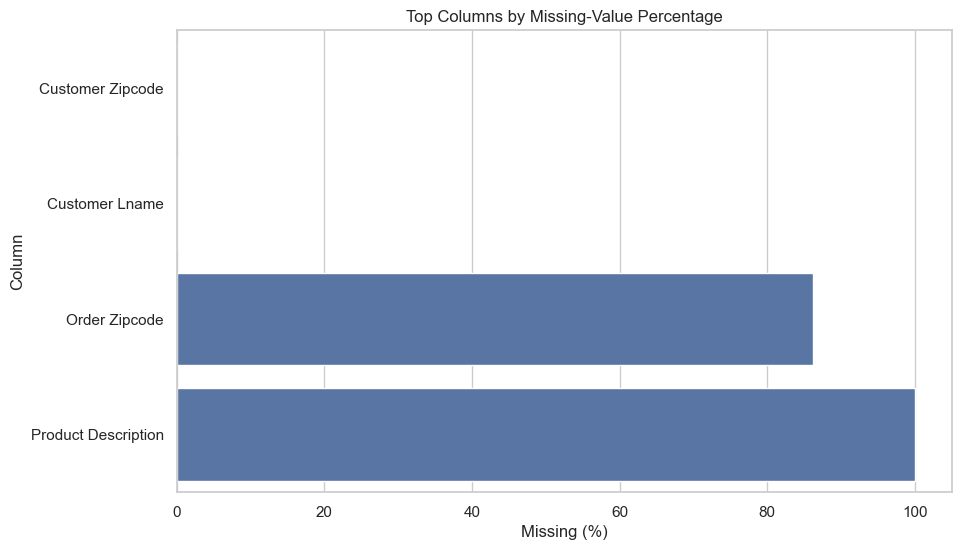

In [6]:
missing_plot = missing[missing["Missing_Count"] > 0].head(15).sort_values("Missing_%")

plt.figure(figsize=(10, 6))
sns.barplot(data=missing_plot, x="Missing_%", y=missing_plot.index)
plt.title("Top Columns by Missing-Value Percentage")
plt.xlabel("Missing (%)")
plt.ylabel("Column")
plt.show()

## 6. Duplicate and Uniqueness Analysis

In [7]:
duplicate_rows = df_raw.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_rows:,}")
print(f"Duplicate percentage: {duplicate_rows / len(df_raw) * 100:.2f}%")

unique_report = pd.DataFrame({
    "Column": df_raw.columns,
    "Unique_Values": [df_raw[c].nunique(dropna=True) for c in df_raw.columns],
    "Unique_%": [df_raw[c].nunique(dropna=True) / len(df_raw) * 100 for c in df_raw.columns]
}).sort_values("Unique_Values")

display(unique_report.head(20))

Exact duplicate rows: 0
Duplicate percentage: 0.00%


,Column,Unique_Values,Unique_%
46,Product Description,0,0.00
15,Customer Password,1,0.00
50,Product Status,1,0.00
11,Customer Email,1,0.00
6,Late_delivery_risk,2,0.00
10,Customer Country,2,0.00
16,Customer Segment,3,0.00
5,Delivery Status,4,0.00
2,Days for shipment (scheduled),4,0.00
52,Shipping Mode,4,0.00


## 7. Identify PII / Unnecessary Columns

Customer passwords, emails, names and street addresses are not needed for analytics and should not be included in a portfolio dataset.

In [8]:
pii_or_unnecessary = [
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Customer Zipcode",
    "Order Zipcode",
    "Product Image",
    "Product Description"
]

existing_drop = [c for c in pii_or_unnecessary if c in df_raw.columns]

print("Columns excluded from analytics:")
print(existing_drop)

Columns excluded from analytics:
['Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname', 'Customer Street', 'Customer Zipcode', 'Order Zipcode', 'Product Image', 'Product Description']


## 8. Create the Analytics Dataset and Standardize Column Names

In [9]:
df = df_raw.drop(columns=existing_drop, errors="ignore").copy()

rename_map = {
    "Days for shipping (real)": "Actual_Shipping_Days",
    "Days for shipment (scheduled)": "Scheduled_Shipping_Days",
    "Benefit per order": "Benefit_Per_Order",
    "Sales per customer": "Sales_Per_Customer",
    "Delivery Status": "Delivery_Status",
    "Late_delivery_risk": "Late_Delivery_Risk",
    "Category Id": "Category_ID",
    "Category Name": "Category_Name",
    "Customer Id": "Customer_ID",
    "Customer Segment": "Customer_Segment",
    "Department Id": "Department_ID",
    "Department Name": "Department_Name",
    "Order City": "Order_City",
    "Order Country": "Order_Country",
    "Order Customer Id": "Order_Customer_ID",
    "Order Item Cardprod Id": "Order_Item_Product_ID",
    "Order Item Discount": "Order_Item_Discount",
    "Order Item Discount Rate": "Order_Item_Discount_Rate",
    "Order Item Id": "Order_Item_ID",
    "Order Item Product Price": "Order_Item_Product_Price",
    "Order Item Profit Ratio": "Order_Item_Profit_Ratio",
    "Order Item Quantity": "Order_Item_Quantity",
    "Order Item Total": "Order_Item_Total",
    "Order Profit Per Order": "Order_Profit_Per_Order",
    "Order Region": "Order_Region",
    "Order State": "Order_State",
    "Order Status": "Order_Status",
    "Product Card Id": "Product_Card_ID",
    "Product Category Id": "Product_Category_ID",
    "Product Name": "Product_Name",
    "Product Price": "Product_Price",
    "Product Status": "Product_Status",
    "Shipping Mode": "Shipping_Mode",
    "Latitude": "Customer_Latitude",
    "Longitude": "Customer_Longitude",
    "Order Id": "Order_ID",
    "Type": "Transaction_Type",
    "shipping date (DateOrders)": "Shipping_Date",
    "order date (DateOrders)": "Order_Date"
}

df = df.rename(columns=rename_map)

df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Shipping_Date"] = pd.to_datetime(df["Shipping_Date"], errors="coerce")

print("Analytics dataset shape:", df.shape)
display(df.head())

Analytics dataset shape: (180519, 44)


,Transaction_Type,Actual_Shipping_Days,Scheduled_Shipping_Days,Benefit_Per_Order,Sales_Per_Customer,Delivery_Status,Late_Delivery_Risk,Category_ID,Category_Name,Customer City,Customer Country,Customer_ID,Customer_Segment,Customer State,Department_ID,Department_Name,Customer_Latitude,Customer_Longitude,Market,Order_City,Order_Country,Order_Customer_ID,Order_Date,Order_ID,Order_Item_Product_ID,Order_Item_Discount,Order_Item_Discount_Rate,Order_Item_ID,Order_Item_Product_Price,Order_Item_Profit_Ratio,Order_Item_Quantity,Sales,Order_Item_Total,Order_Profit_Per_Order,Order_Region,Order_State,Order_Status,Product_Card_ID,Product_Category_ID,Product_Name,Product_Price,Product_Status,Shipping_Date,Shipping_Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,19490,Home Office,CA,2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,19489,Corporate,PR,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class


## 9. Data Quality Validation

In [10]:
numeric_candidates = [
    "Sales", "Order_Profit_Per_Order", "Order_Item_Quantity",
    "Actual_Shipping_Days", "Scheduled_Shipping_Days",
    "Order_Item_Discount", "Order_Item_Discount_Rate"
]

print("Invalid / missing numeric values:")
for col in numeric_candidates:
    if col in df.columns:
        print(f"{col}: {df[col].isna().sum():,} missing")

print("\nNegative sales:", (df["Sales"] < 0).sum())
print("Zero quantity:", (df["Order_Item_Quantity"] == 0).sum())
print("Negative actual shipping days:", (df["Actual_Shipping_Days"] < 0).sum())
print("Invalid order dates:", df["Order_Date"].isna().sum())

Invalid / missing numeric values:
Sales: 0 missing
Order_Profit_Per_Order: 0 missing
Order_Item_Quantity: 0 missing
Actual_Shipping_Days: 0 missing
Scheduled_Shipping_Days: 0 missing
Order_Item_Discount: 0 missing
Order_Item_Discount_Rate: 0 missing

Negative sales: 0
Zero quantity: 0
Negative actual shipping days: 0
Invalid order dates: 0


## 10. Remove Duplicate Order-Item Records and Invalid Dates

In [11]:
before = len(df)

df = df.drop_duplicates(subset=["Order_Item_ID"])
df = df[df["Order_Date"].notna()].copy()

after = len(df)

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {after:,}")
print(f"Rows removed:         {before-after:,}")

Rows before cleaning: 180,519
Rows after cleaning:  180,519
Rows removed:         0


## 11. Feature Engineering

In [12]:
# Delivery / operational features
df["Shipping_Delay_Days"] = (
    df["Actual_Shipping_Days"] - df["Scheduled_Shipping_Days"]
).clip(lower=0)

df["On_Time_Flag"] = (
    df["Delivery_Status"].eq("Shipping on time")
).astype(int)

df["Late_Flag"] = (
    df["Delivery_Status"].eq("Late delivery")
).astype(int)

df["Early_Flag"] = (
    df["Delivery_Status"].eq("Advance shipping")
).astype(int)

# Time features
df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_Quarter"] = df["Order_Date"].dt.quarter
df["Month_Name"] = df["Order_Date"].dt.strftime("%b")
df["Year_Month"] = df["Order_Date"].dt.to_period("M").astype(str)
df["Day_of_Week"] = df["Order_Date"].dt.day_name()

# Profitability
df["Calculated_Profit_Margin_%"] = np.where(
    df["Sales"] != 0,
    df["Order_Profit_Per_Order"] / df["Sales"] * 100,
    np.nan
)

# Revenue after discount
df["Revenue_After_Discount"] = df["Sales"] - df["Order_Item_Discount"]

print("Feature engineering complete.")
display(df[[
    "Order_ID", "Order_Date", "Sales", "Order_Profit_Per_Order",
    "Shipping_Delay_Days", "On_Time_Flag", "Late_Flag",
    "Year_Month", "Calculated_Profit_Margin_%"
]].head())

Feature engineering complete.


,Order_ID,Order_Date,Sales,Order_Profit_Per_Order,Shipping_Delay_Days,On_Time_Flag,Late_Flag,Year_Month,Calculated_Profit_Margin_%
0,77202,2018-01-31 22:56:00,327.75,91.25,0,0,0,2018-01,27.84
1,75939,2018-01-13 12:27:00,327.75,-249.09,1,0,1,2018-01,-76.00
2,75938,2018-01-13 12:06:00,327.75,-247.78,0,1,0,2018-01,-75.60
3,75937,2018-01-13 11:45:00,327.75,22.86,0,0,0,2018-01,6.97
4,75936,2018-01-13 11:24:00,327.75,134.21,0,0,0,2018-01,40.95


## 12. Executive KPI Dashboard

In [13]:
kpis = pd.Series({
    "Order Items": df["Order_Item_ID"].nunique(),
    "Orders": df["Order_ID"].nunique(),
    "Customers": df["Customer_ID"].nunique(),
    "Products": df["Product_Card_ID"].nunique(),
    "Revenue": df["Sales"].sum(),
    "Profit": df["Order_Profit_Per_Order"].sum(),
    "Profit Margin %": df["Order_Profit_Per_Order"].sum() / df["Sales"].sum() * 100,
    "On-Time Delivery %": df["On_Time_Flag"].mean() * 100,
    "Late Delivery %": df["Late_Flag"].mean() * 100,
    "Average Actual Shipping Days": df["Actual_Shipping_Days"].mean(),
    "Average Scheduled Shipping Days": df["Scheduled_Shipping_Days"].mean(),
    "Average Order-Item Quantity": df["Order_Item_Quantity"].mean()
})

display(kpis.to_frame("Value"))

,Value
Order Items,"180,519.00"
Orders,"65,752.00"
Customers,"20,652.00"
Products,118.00
Revenue,"36,784,735.01"
Profit,"3,966,902.97"
Profit Margin %,10.78
On-Time Delivery %,17.84
Late Delivery %,54.83
Average Actual Shipping Days,3.50


## 13. Revenue and Profit Over Time

In [14]:
monthly = (
    df.groupby("Year_Month")
      .agg(
          Revenue=("Sales", "sum"),
          Profit=("Order_Profit_Per_Order", "sum"),
          Orders=("Order_ID", "nunique"),
          Quantity=("Order_Item_Quantity", "sum"),
          On_Time_Rate=("On_Time_Flag", "mean"),
          Late_Rate=("Late_Flag", "mean")
      )
      .reset_index()
)

monthly["On_Time_Rate"] *= 100
monthly["Late_Rate"] *= 100
monthly["MoM_Revenue_Growth_%"] = monthly["Revenue"].pct_change() * 100

display(monthly.head())

,Year_Month,Revenue,Profit,Orders,Quantity,On_Time_Rate,Late_Rate,MoM_Revenue_Growth_%
0,2015-01,"1,051,590.08","111,660.74",1787,11854,18.60,54.11,NaN
1,2015-02,"927,009.90","99,140.66",1585,10438,16.90,54.85,-11.85
2,2015-03,"1,051,253.69","113,778.21",1781,12062,17.79,54.76,13.40
3,2015-04,"1,014,463.28","108,083.68",1710,11287,18.10,53.84,-3.50
4,2015-05,"1,050,478.44","112,147.90",1776,11902,16.89,55.09,3.55


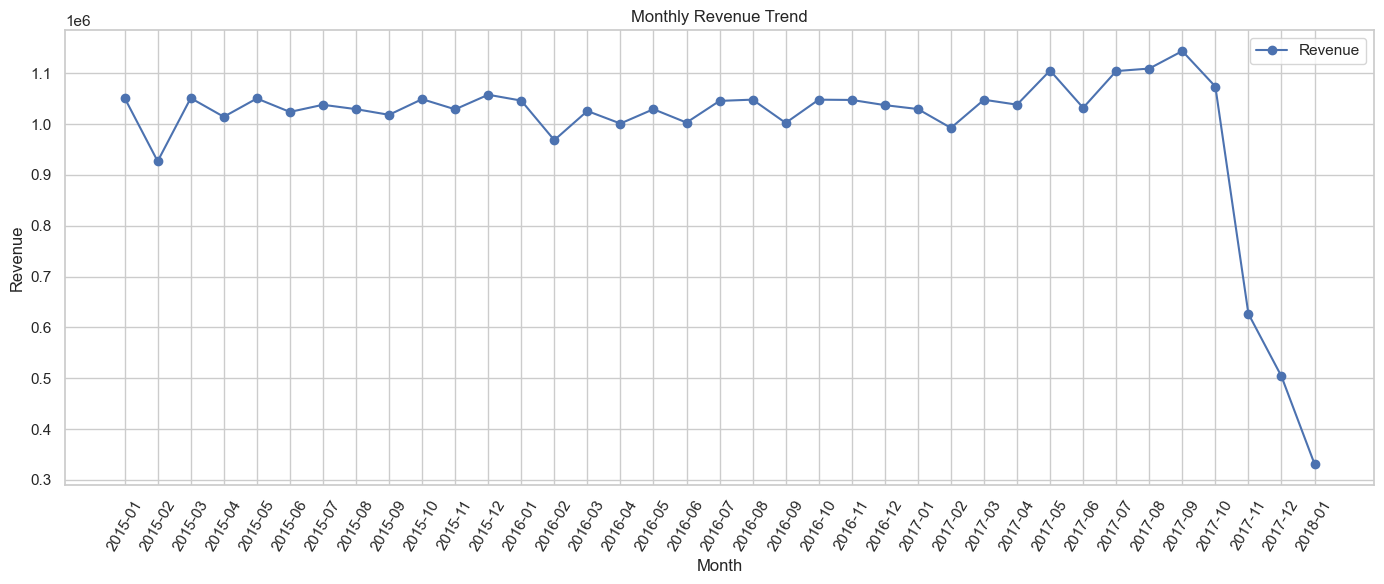

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly["Year_Month"], monthly["Revenue"], marker="o", label="Revenue")
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.tick_params(axis="x", rotation=60)
ax.legend()
plt.tight_layout()
plt.show()

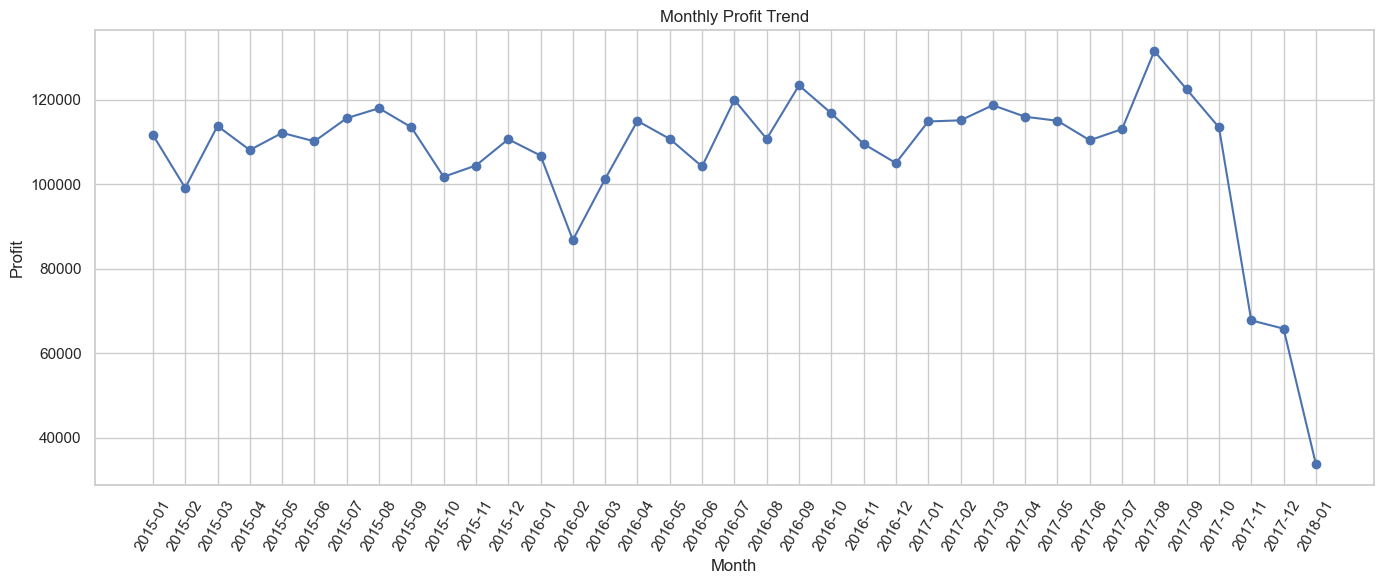

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly["Year_Month"], monthly["Profit"], marker="o")
ax.set_title("Monthly Profit Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Profit")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

## 14. Category Performance

In [17]:
category_perf = (
    df.groupby("Category_Name")
      .agg(
          Revenue=("Sales","sum"),
          Profit=("Order_Profit_Per_Order","sum"),
          Quantity=("Order_Item_Quantity","sum"),
          Orders=("Order_ID","nunique"),
          Late_Rate=("Late_Flag","mean")
      )
      .reset_index()
)

category_perf["Profit_Margin_%"] = category_perf["Profit"] / category_perf["Revenue"] * 100
category_perf["Late_Rate"] *= 100
category_perf = category_perf.sort_values("Revenue", ascending=False)

display(category_perf)

,Category_Name,Revenue,Profit,Quantity,Orders,Late_Rate,Profit_Margin_%
18,Fishing,"6,929,653.69","756,220.77",17325,15164,54.93,10.91
12,Cleats,"4,431,942.78","494,636.92",73734,20386,54.97,11.16
9,Camping & Hiking,"4,118,425.57","427,455.57",13729,12299,54.53,10.38
10,Cardio Equipment,"3,694,843.20","383,011.10",37587,11355,54.50,10.37
47,Women's Apparel,"3,147,800.00","350,421.03",62956,17869,54.56,11.13
46,Water Sports,"3,113,844.68","325,146.96",15540,13758,54.81,10.44
34,Men's Footwear,"2,891,757.66","311,902.82",22246,18783,54.49,10.79
30,Indoor/Outdoor Games,"2,888,993.91","318,451.43",57803,16623,54.75,11.02
38,Shop By Sport,"1,309,522.04","129,813.96",32726,10136,55.15,9.91
13,Computers,"663,000.00","69,656.81",442,442,50.68,10.51


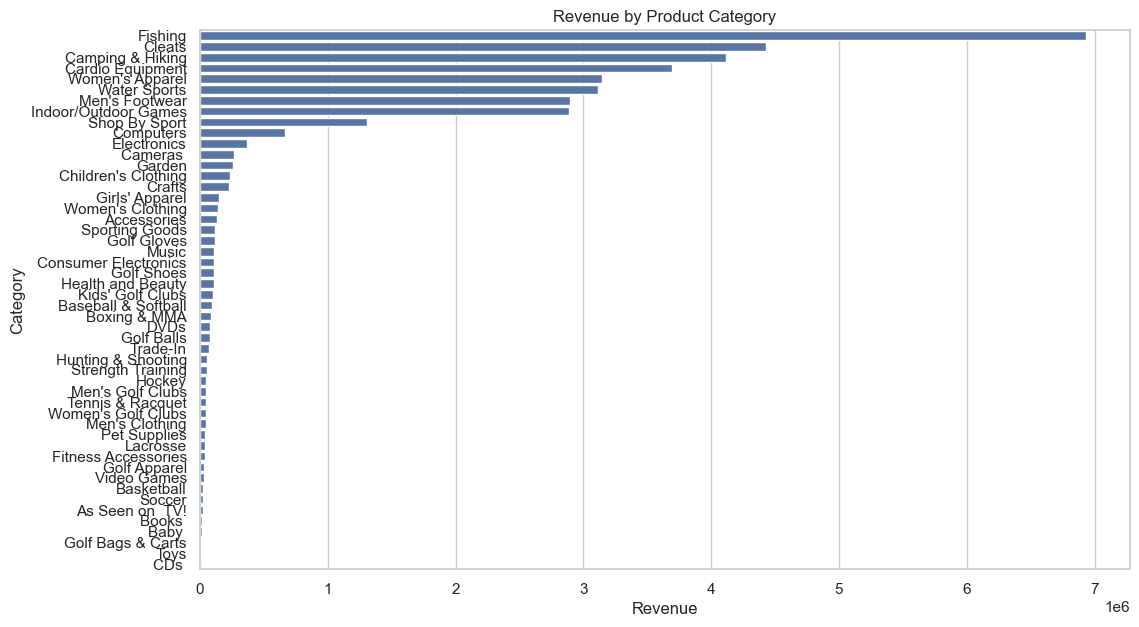

In [18]:
plt.figure(figsize=(12, 7))
sns.barplot(data=category_perf, x="Revenue", y="Category_Name")
plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

## 15. Product Analysis

In [19]:
product_perf = (
    df.groupby(["Product_Card_ID", "Product_Name"])
      .agg(
          Revenue=("Sales","sum"),
          Profit=("Order_Profit_Per_Order","sum"),
          Quantity=("Order_Item_Quantity","sum"),
          Orders=("Order_ID","nunique"),
          Late_Rate=("Late_Flag","mean")
      )
      .reset_index()
)

product_perf["Profit_Margin_%"] = product_perf["Profit"] / product_perf["Revenue"] * 100
product_perf["Late_Rate"] *= 100

top_products = product_perf.sort_values("Revenue", ascending=False).head(15)

display(top_products)

,Product_Card_ID,Product_Name,Revenue,Profit,Quantity,Orders,Late_Rate,Profit_Margin_%
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,"6,929,653.69","756,220.77",17325,15164,54.93,10.91
35,365,Perfect Fitness Perfect Rip Deck,"4,421,143.14","493,828.30",73698,20359,54.96,11.17
92,957,Diamondback Women's Serene Classic Comfort Bi,"4,118,425.57","427,455.57",13729,12299,54.53,10.38
15,191,Nike Men's Free 5.0+ Running Shoe,"3,667,633.20","379,915.82",36680,11092,54.47,10.36
37,502,Nike Men's Dri-FIT Victory Golf Polo,"3,147,800.00","350,421.03",62956,17869,54.56,11.13
99,1073,Pelican Sunstream 100 Kayak,"3,099,845.09","324,076.37",15500,13727,54.79,10.45
36,403,Nike Men's CJ Elite 2 TD Football Cleat,"2,891,757.66","311,902.82",22246,18783,54.49,10.79
97,1014,O'Brien Men's Neoprene Life Vest,"2,888,993.91","318,451.43",57803,16623,54.75,11.02
44,627,Under Armour Girls' Toddler Spine Surge Runni,"1,269,082.67","126,278.51",31735,9825,55.24,9.95
105,1351,Dell Laptop,"663,000.00","69,656.81",442,442,50.68,10.51


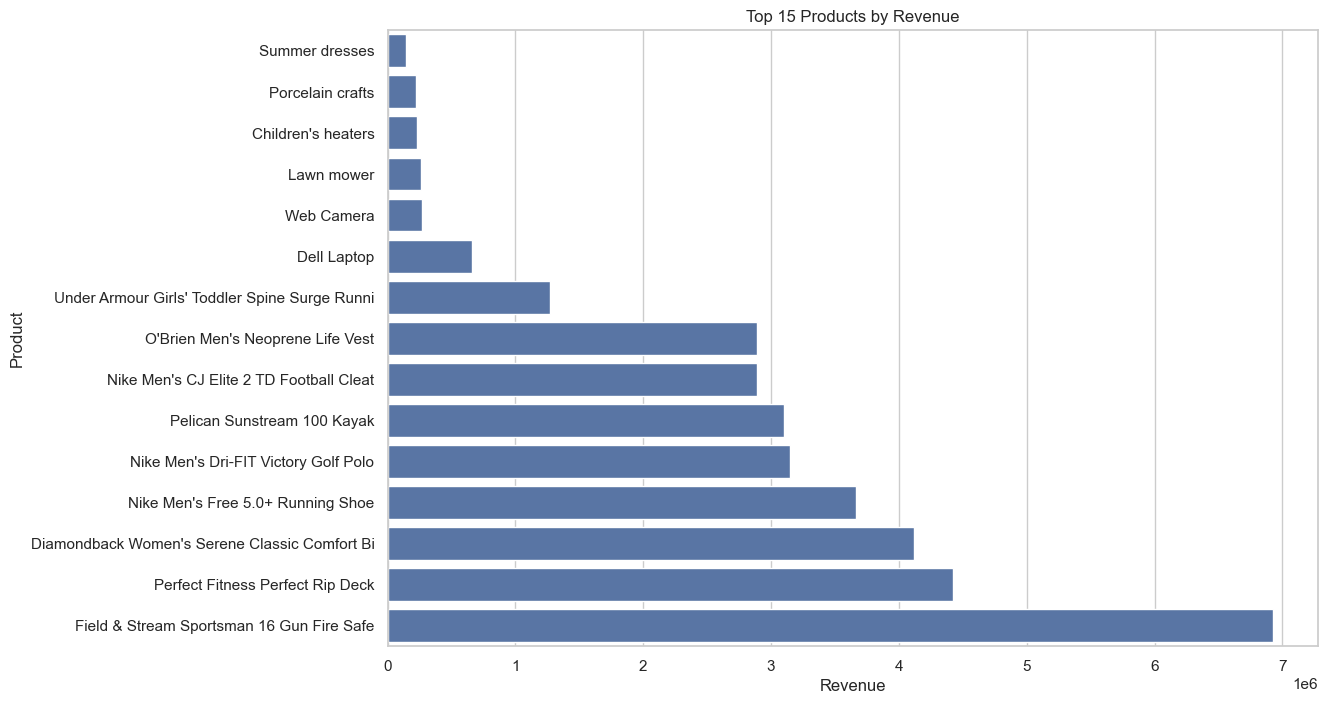

In [20]:
plt.figure(figsize=(12, 8))
sns.barplot(data=top_products.sort_values("Revenue"), x="Revenue", y="Product_Name")
plt.title("Top 15 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

## 16. High-Revenue but Low-Margin Products

In [21]:
median_margin = product_perf["Profit_Margin_%"].median()
median_revenue = product_perf["Revenue"].median()

high_revenue_low_margin = product_perf[
    (product_perf["Revenue"] >= median_revenue) &
    (product_perf["Profit_Margin_%"] < median_margin)
].sort_values("Revenue", ascending=False)

print(f"Median product revenue: {median_revenue:,.2f}")
print(f"Median product margin: {median_margin:.2f}%")
display(high_revenue_low_margin.head(20))

Median product revenue: 20,582.35
Median product margin: 11.00%


,Product_Card_ID,Product_Name,Revenue,Profit,Quantity,Orders,Late_Rate,Profit_Margin_%
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,"6,929,653.69","756,220.77",17325,15164,54.93,10.91
92,957,Diamondback Women's Serene Classic Comfort Bi,"4,118,425.57","427,455.57",13729,12299,54.53,10.38
15,191,Nike Men's Free 5.0+ Running Shoe,"3,667,633.20","379,915.82",36680,11092,54.47,10.36
99,1073,Pelican Sunstream 100 Kayak,"3,099,845.09","324,076.37",15500,13727,54.79,10.45
36,403,Nike Men's CJ Elite 2 TD Football Cleat,"2,891,757.66","311,902.82",22246,18783,54.49,10.79
44,627,Under Armour Girls' Toddler Spine Surge Runni,"1,269,082.67","126,278.51",31735,9825,55.24,9.95
105,1351,Dell Laptop,"663,000.00","69,656.81",442,442,50.68,10.51
114,1360,Smart watch,"117,006.75","12,518.61",357,357,55.46,10.70
110,1356,First aid kit,"106,080.48","9,493.63",362,362,55.80,8.95
108,1354,DVDs,"79,395.54","6,655.43",483,483,53.62,8.38


## 17. Market Performance

In [22]:
market_perf = (
    df.groupby("Market")
      .agg(
          Revenue=("Sales","sum"),
          Profit=("Order_Profit_Per_Order","sum"),
          Orders=("Order_ID","nunique"),
          Customers=("Customer_ID","nunique"),
          Late_Rate=("Late_Flag","mean")
      )
      .reset_index()
)

market_perf["Profit_Margin_%"] = market_perf["Profit"] / market_perf["Revenue"] * 100
market_perf["Late_Rate"] *= 100

display(market_perf.sort_values("Revenue", ascending=False))

,Market,Revenue,Profit,Orders,Customers,Late_Rate,Profit_Margin_%
1,Europe,"10,872,396.80","1,169,442.96",18561,11657,55.21,10.76
2,LATAM,"10,277,612.84","1,123,321.61",17181,9325,54.36,10.93
3,Pacific Asia,"8,273,743.74","857,753.44",17577,13267,55.05,10.37
4,USCA,"5,066,528.71","564,313.78",8579,6256,54.80,11.14
0,Africa,"2,294,452.93","252,071.18",3854,3311,54.59,10.99


## 18. Customer Segment Analysis

In [23]:
segment_perf = (
    df.groupby("Customer_Segment")
      .agg(
          Revenue=("Sales","sum"),
          Profit=("Order_Profit_Per_Order","sum"),
          Orders=("Order_ID","nunique"),
          Customers=("Customer_ID","nunique"),
          Quantity=("Order_Item_Quantity","sum"),
          Late_Rate=("Late_Flag","mean")
      )
      .reset_index()
)

segment_perf["Revenue_per_Order"] = segment_perf["Revenue"] / segment_perf["Orders"]
segment_perf["Profit_Margin_%"] = segment_perf["Profit"] / segment_perf["Revenue"] * 100
segment_perf["Late_Rate"] *= 100

display(segment_perf.sort_values("Revenue", ascending=False))

,Customer_Segment,Revenue,Profit,Orders,Customers,Quantity,Late_Rate,Revenue_per_Order,Profit_Margin_%
0,Consumer,"19,095,790.16","2,073,487.67",34119,10695,199234,54.81,559.68,10.86
1,Corporate,"11,168,406.84","1,202,574.96",19856,6239,116560,54.72,562.47,10.77
2,Home Office,"6,520,538.02","690,840.34",11777,3718,68285,55.07,553.67,10.59


## 19. Shipping Mode Analysis

In [24]:
shipping_perf = (
    df.groupby("Shipping_Mode")
      .agg(
          Orders=("Order_ID","nunique"),
          Revenue=("Sales","sum"),
          Avg_Actual_Days=("Actual_Shipping_Days","mean"),
          Avg_Scheduled_Days=("Scheduled_Shipping_Days","mean"),
          Avg_Delay_Days=("Shipping_Delay_Days","mean"),
          Late_Rate=("Late_Flag","mean"),
          On_Time_Rate=("On_Time_Flag","mean")
      )
      .reset_index()
)

shipping_perf["Late_Rate"] *= 100
shipping_perf["On_Time_Rate"] *= 100

display(shipping_perf.sort_values("Late_Rate", ascending=False))

,Shipping_Mode,Orders,Revenue,Avg_Actual_Days,Avg_Scheduled_Days,Avg_Delay_Days,Late_Rate,On_Time_Rate
0,First Class,10079,"5,674,369.76",2.00,1.00,1.00,95.32,0.00
2,Second Class,12778,"7,145,444.82",3.99,2.00,1.99,76.63,19.36
1,Same Day,3571,"1,942,528.56",0.48,0.00,0.48,45.74,49.70
3,Standard Class,39324,"22,022,391.88",4.00,4.00,0.60,38.07,19.06


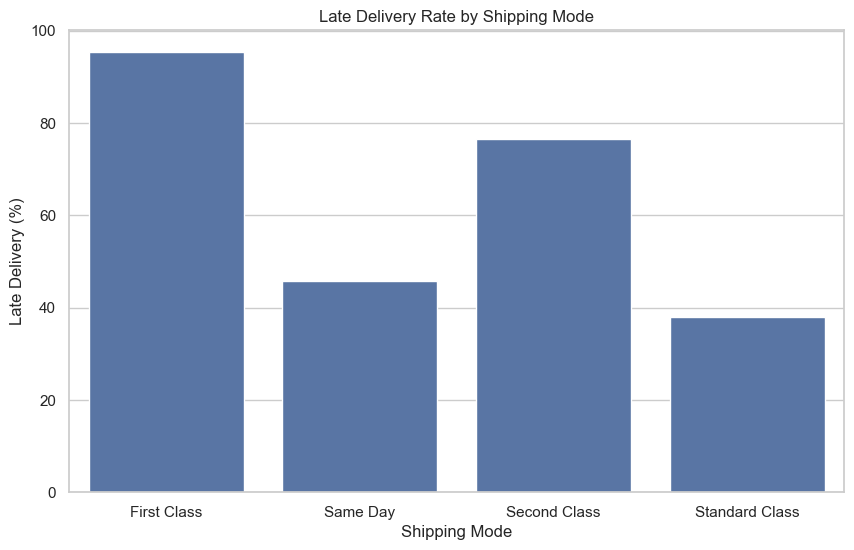

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(data=shipping_perf, x="Shipping_Mode", y="Late_Rate")
plt.title("Late Delivery Rate by Shipping Mode")
plt.ylabel("Late Delivery (%)")
plt.xlabel("Shipping Mode")
plt.show()

## 20. Delivery Status Analysis

In [26]:
delivery = (
    df["Delivery_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentage")
    .to_frame()
)

display(delivery)

,Percentage
Delivery_Status,
Late delivery,54.83
Advance shipping,23.04
Shipping on time,17.84
Shipping canceled,4.30


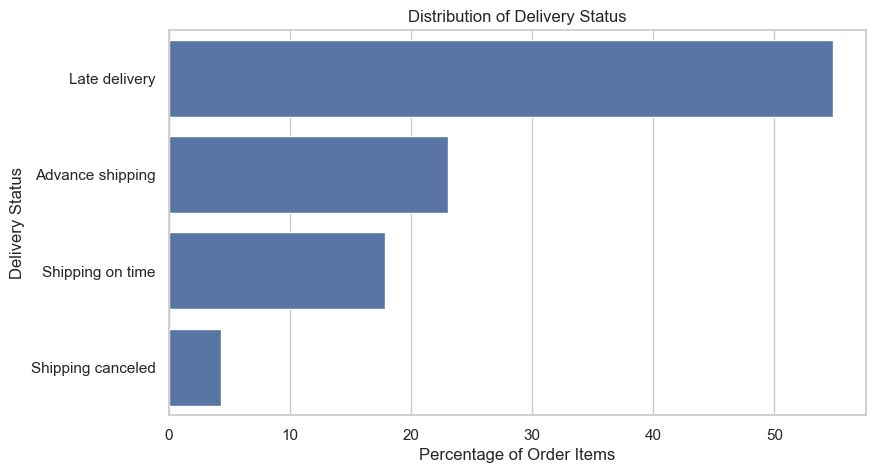

In [27]:
plt.figure(figsize=(9, 5))
sns.barplot(data=delivery.reset_index(), x="Percentage", y="Delivery_Status")
plt.title("Distribution of Delivery Status")
plt.xlabel("Percentage of Order Items")
plt.ylabel("Delivery Status")
plt.show()

## 21. Order Status Analysis

In [28]:
order_status = (
    df.groupby("Order_Status")
      .agg(
          Orders=("Order_ID","nunique"),
          Revenue=("Sales","sum"),
          Profit=("Order_Profit_Per_Order","sum")
      )
      .reset_index()
      .sort_values("Revenue", ascending=False)
)

display(order_status)

,Order_Status,Orders,Revenue,Profit
2,COMPLETE,21716,"12,095,314.95","1,321,735.75"
6,PENDING_PAYMENT,14382,"8,106,697.56","843,810.24"
7,PROCESSING,7901,"4,504,063.75","494,825.87"
5,PENDING,7321,"4,120,532.87","435,725.85"
1,CLOSED,7249,"4,022,624.17","457,981.09"
3,ON_HOLD,3624,"1,981,542.71","208,913.04"
8,SUSPECTED_FRAUD,1488,"825,934.96","85,136.71"
0,CANCELED,1367,"744,370.40","75,345.63"
4,PAYMENT_REVIEW,704,"383,653.66","43,428.79"


## 22. Geographic Analysis — Countries

In [29]:
country_perf = (
    df.groupby("Order_Country")
      .agg(
          Revenue=("Sales","sum"),
          Profit=("Order_Profit_Per_Order","sum"),
          Orders=("Order_ID","nunique"),
          Late_Rate=("Late_Flag","mean")
      )
      .reset_index()
)

country_perf["Late_Rate"] *= 100

# Focus on countries with meaningful volume
country_perf_filtered = country_perf[country_perf["Orders"] >= 100]

display(country_perf_filtered.sort_values("Revenue", ascending=False).head(20))

,Order_Country,Revenue,Profit,Orders,Late_Rate
48,Estados Unidos,"4,879,667.67","540,413.07",8270,55.03
53,Francia,"2,879,942.36","327,828.58",4866,55.52
102,México,"2,633,195.29","303,278.37",4395,55.01
2,Alemania,"2,074,171.82","194,827.08",3518,56.28
8,Australia,"1,694,621.67","170,041.58",3798,54.29
120,Reino Unido,"1,612,094.85","180,942.88",2785,53.45
20,Brasil,"1,594,319.95","186,713.64",2650,54.23
31,China,"1,172,902.11","122,190.92",2616,54.24
75,Italia,"1,072,181.67","121,545.47",1880,53.56
69,India,"962,396.70","99,746.82",2152,56.12


## 23. Geographic Analysis — Regions

In [30]:
region_perf = (
    df.groupby("Order_Region")
      .agg(
          Revenue=("Sales","sum"),
          Profit=("Order_Profit_Per_Order","sum"),
          Orders=("Order_ID","nunique"),
          Late_Rate=("Late_Flag","mean")
      )
      .reset_index()
)

region_perf["Late_Rate"] *= 100
display(region_perf.sort_values("Revenue", ascending=False))

,Order_Region,Revenue,Profit,Orders,Late_Rate
22,Western Europe,"5,894,380.77","625,446.08",10010,55.85
3,Central America,"5,665,712.10","616,341.57",9396,54.75
12,South America,"2,960,881.41","335,154.40",4979,54.31
10,Northern Europe,"2,155,830.65","233,450.60",3716,54.04
17,Southern Europe,"2,047,918.82","230,829.23",3543,54.38
11,Oceania,"2,016,654.20","201,478.02",4362,54.02
15,Southeast Asia,"1,932,495.57","211,342.82",4356,55.53
1,Caribbean,"1,651,019.33","171,825.64",2806,53.08
21,West of USA,"1,571,415.96","164,940.66",2667,53.96
13,South Asia,"1,553,680.92","165,703.90",3335,56.27


## 24. Discount Analysis

In [31]:
discount_analysis = (
    df.groupby("Order_Item_Discount_Rate")
      .agg(
          Orders=("Order_ID","nunique"),
          Revenue=("Sales","sum"),
          Profit=("Order_Profit_Per_Order","sum"),
          Avg_Profit=("Order_Profit_Per_Order","mean")
      )
      .reset_index()
      .sort_values("Order_Item_Discount_Rate")
)

display(discount_analysis)

,Order_Item_Discount_Rate,Orders,Revenue,Profit,Avg_Profit
0,0.00,9400,"2,042,369.18","267,412.40",26.67
1,0.01,9356,"2,042,793.05","238,653.96",23.80
2,0.02,9364,"2,042,818.15","237,401.16",23.67
3,0.03,9403,"2,043,343.82","222,475.43",22.18
4,0.04,9364,"2,043,377.90","234,683.30",23.40
5,0.05,9366,"2,043,412.89","238,468.23",23.78
6,0.06,9376,"2,043,421.44","241,415.97",24.07
7,0.07,9384,"2,043,451.89","233,404.92",23.27
8,0.09,9385,"2,043,478.43","229,769.42",22.91
9,0.10,9377,"2,043,500.52","221,921.32",22.13


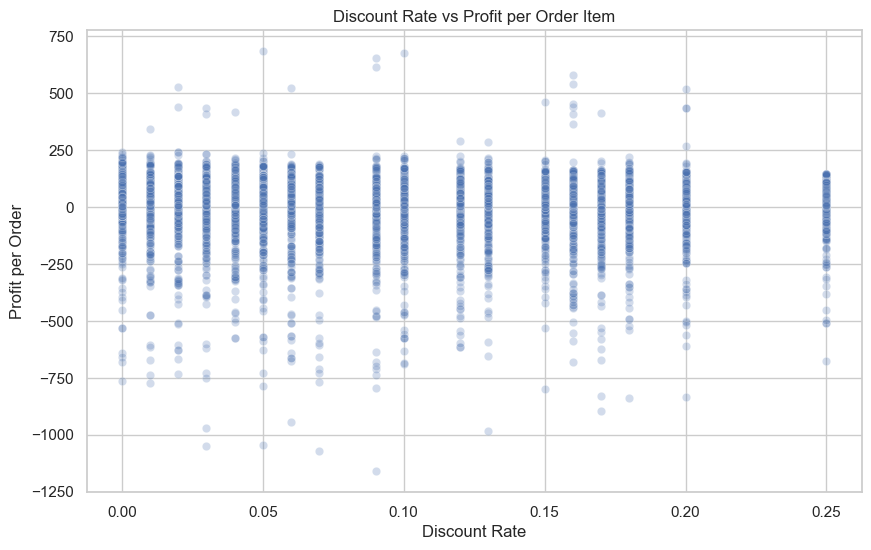

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(15000, len(df)), random_state=42),
    x="Order_Item_Discount_Rate",
    y="Order_Profit_Per_Order",
    alpha=0.25
)
plt.title("Discount Rate vs Profit per Order Item")
plt.xlabel("Discount Rate")
plt.ylabel("Profit per Order")
plt.show()

## 25. Correlation Analysis

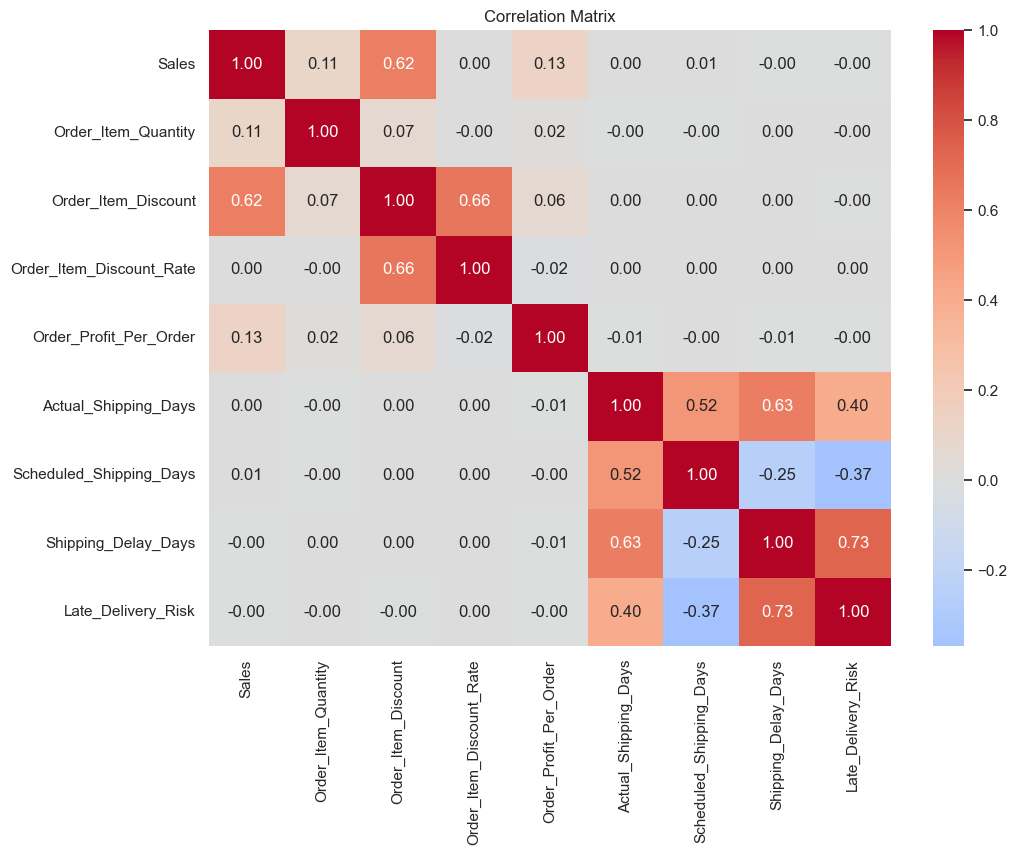

In [33]:
corr_cols = [
    "Sales",
    "Order_Item_Quantity",
    "Order_Item_Discount",
    "Order_Item_Discount_Rate",
    "Order_Profit_Per_Order",
    "Actual_Shipping_Days",
    "Scheduled_Shipping_Days",
    "Shipping_Delay_Days",
    "Late_Delivery_Risk"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## 26. Statistical Test — Discount Rate and Profit

We compare profit between lower-discount and higher-discount order items. This is exploratory and does **not** establish causation because other factors may differ between groups.

In [34]:
median_discount = df["Order_Item_Discount_Rate"].median()

low_discount_profit = df.loc[
    df["Order_Item_Discount_Rate"] <= median_discount,
    "Order_Profit_Per_Order"
].dropna()

high_discount_profit = df.loc[
    df["Order_Item_Discount_Rate"] > median_discount,
    "Order_Profit_Per_Order"
].dropna()

t_stat, p_value = stats.ttest_ind(
    low_discount_profit,
    high_discount_profit,
    equal_var=False
)

print(f"Median discount rate: {median_discount:.4f}")
print(f"Low-discount mean profit: {low_discount_profit.mean():.2f}")
print(f"High-discount mean profit: {high_discount_profit.mean():.2f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

Median discount rate: 0.1000
Low-discount mean profit: 23.59
High-discount mean profit: 19.96
t-statistic: 7.4516
p-value: 0.000000


## 27. Statistical Test — Shipping Delay and Profit

Compare order-item profit for items with and without a shipping delay.

In [35]:
no_delay_profit = df.loc[
    df["Shipping_Delay_Days"] == 0,
    "Order_Profit_Per_Order"
].dropna()

delayed_profit = df.loc[
    df["Shipping_Delay_Days"] > 0,
    "Order_Profit_Per_Order"
].dropna()

t_stat_delay, p_value_delay = stats.ttest_ind(
    no_delay_profit,
    delayed_profit,
    equal_var=False
)

print(f"No-delay mean profit: {no_delay_profit.mean():.2f}")
print(f"Delayed mean profit: {delayed_profit.mean():.2f}")
print(f"t-statistic: {t_stat_delay:.4f}")
print(f"p-value: {p_value_delay:.6f}")

No-delay mean profit: 22.50
Delayed mean profit: 21.59
t-statistic: 1.8391
p-value: 0.065908


## 28. Pareto Analysis — Revenue Concentration

In [36]:
product_pareto = (
    product_perf.sort_values("Revenue", ascending=False)
    .reset_index(drop=True)
)

product_pareto["Cumulative_Revenue"] = product_pareto["Revenue"].cumsum()
product_pareto["Cumulative_Revenue_%"] = (
    product_pareto["Cumulative_Revenue"] /
    product_pareto["Revenue"].sum() * 100
)

products_for_80 = (
    product_pareto["Cumulative_Revenue_%"] <= 80
).sum()

print(f"Number of products contributing to the first ~80% of revenue: {products_for_80}")
display(product_pareto.head(20))

Number of products contributing to the first ~80% of revenue: 7


,Product_Card_ID,Product_Name,Revenue,Profit,Quantity,Orders,Late_Rate,Profit_Margin_%,Cumulative_Revenue,Cumulative_Revenue_%
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,"6,929,653.69","756,220.77",17325,15164,54.93,10.91,"6,929,653.69",18.84
1,365,Perfect Fitness Perfect Rip Deck,"4,421,143.14","493,828.30",73698,20359,54.96,11.17,"11,350,796.83",30.86
2,957,Diamondback Women's Serene Classic Comfort Bi,"4,118,425.57","427,455.57",13729,12299,54.53,10.38,"15,469,222.41",42.05
3,191,Nike Men's Free 5.0+ Running Shoe,"3,667,633.20","379,915.82",36680,11092,54.47,10.36,"19,136,855.60",52.02
4,502,Nike Men's Dri-FIT Victory Golf Polo,"3,147,800.00","350,421.03",62956,17869,54.56,11.13,"22,284,655.60",60.58
5,1073,Pelican Sunstream 100 Kayak,"3,099,845.09","324,076.37",15500,13727,54.79,10.45,"25,384,500.69",69.01
6,403,Nike Men's CJ Elite 2 TD Football Cleat,"2,891,757.66","311,902.82",22246,18783,54.49,10.79,"28,276,258.35",76.87
7,1014,O'Brien Men's Neoprene Life Vest,"2,888,993.91","318,451.43",57803,16623,54.75,11.02,"31,165,252.26",84.72
8,627,Under Armour Girls' Toddler Spine Surge Runni,"1,269,082.67","126,278.51",31735,9825,55.24,9.95,"32,434,334.93",88.17
9,1351,Dell Laptop,"663,000.00","69,656.81",442,442,50.68,10.51,"33,097,334.93",89.98


## 29. Customer-Level RFM-Style Analysis

A simplified customer-value analysis using recency, frequency and monetary value.

In [37]:
analysis_date = df["Order_Date"].max() + pd.Timedelta(days=1)

customer = (
    df.groupby("Customer_ID")
      .agg(
          Last_Order=("Order_Date","max"),
          Frequency=("Order_ID","nunique"),
          Monetary=("Sales","sum"),
          Profit=("Order_Profit_Per_Order","sum")
      )
      .reset_index()
)

customer["Recency_Days"] = (
    analysis_date - customer["Last_Order"]
).dt.days

# Quantile scores; duplicates are handled using rank first
customer["R_Score"] = pd.qcut(
    customer["Recency_Days"].rank(method="first"),
    5, labels=[5,4,3,2,1]
).astype(int)

customer["F_Score"] = pd.qcut(
    customer["Frequency"].rank(method="first"),
    5, labels=[1,2,3,4,5]
).astype(int)

customer["M_Score"] = pd.qcut(
    customer["Monetary"].rank(method="first"),
    5, labels=[1,2,3,4,5]
).astype(int)

customer["RFM_Score"] = (
    customer["R_Score"].astype(str) +
    customer["F_Score"].astype(str) +
    customer["M_Score"].astype(str)
)

display(customer.sort_values("Monetary", ascending=False).head(20))

,Customer_ID,Last_Order,Frequency,Monetary,Profit,Recency_Days,R_Score,F_Score,M_Score,RFM_Score
782,791,2017-09-26 01:13:00,13,"10,524.17",-866.38,128,3,5,5,355
9295,9371,2017-09-06 22:58:00,11,"9,299.03","1,346.58",148,3,5,5,355
8694,8766,2017-09-19 16:07:00,11,"9,296.14","1,495.16",135,3,5,5,355
1636,1657,2017-06-07 14:52:00,11,"9,223.71","2,196.92",239,2,5,5,255
2612,2641,2017-08-07 00:56:00,11,"9,130.92","2,441.97",178,3,5,5,355
1271,1288,2017-05-22 12:47:00,12,"9,019.11",403.11,255,2,5,5,255
3672,3710,2017-08-04 01:28:00,14,"9,019.10","1,055.13",181,3,5,5,355
4209,4249,2017-08-18 11:37:00,13,"8,918.85",439.71,167,3,5,5,355
5603,5654,2017-10-01 04:54:00,15,"8,904.95","1,045.36",123,3,5,5,355
5573,5624,2017-09-24 08:35:00,12,"8,761.98","1,178.15",130,3,5,5,355


## 30. Customer Value Segmentation

In [38]:
customer["Value_Segment"] = np.select(
    [
        (customer["R_Score"] >= 4) & (customer["F_Score"] >= 4) & (customer["M_Score"] >= 4),
        (customer["F_Score"] >= 4) & (customer["M_Score"] >= 4),
        (customer["R_Score"] <= 2) & (customer["M_Score"] >= 4)
    ],
    ["High Value / Active", "Frequent High Value", "High Value / At Risk"],
    default="Other"
)

segment_counts = customer["Value_Segment"].value_counts().to_frame("Customers")
display(segment_counts)

,Customers
Value_Segment,
Other,12629
Frequent High Value,7376
High Value / At Risk,647


## 31. Top Customers

In [39]:
top_customers = customer.sort_values("Monetary", ascending=False).head(20)

display(
    top_customers[
        ["Customer_ID","Frequency","Monetary","Profit","Recency_Days","Value_Segment"]
    ]
)

,Customer_ID,Frequency,Monetary,Profit,Recency_Days,Value_Segment
782,791,13,"10,524.17",-866.38,128,Frequent High Value
9295,9371,11,"9,299.03","1,346.58",148,Frequent High Value
8694,8766,11,"9,296.14","1,495.16",135,Frequent High Value
1636,1657,11,"9,223.71","2,196.92",239,Frequent High Value
2612,2641,11,"9,130.92","2,441.97",178,Frequent High Value
1271,1288,12,"9,019.11",403.11,255,Frequent High Value
3672,3710,14,"9,019.10","1,055.13",181,Frequent High Value
4209,4249,13,"8,918.85",439.71,167,Frequent High Value
5603,5654,15,"8,904.95","1,045.36",123,Frequent High Value
5573,5624,12,"8,761.98","1,178.15",130,Frequent High Value


## 32. Operational Bottleneck Analysis

In [40]:
# Identify markets that are both meaningful in volume and have high late-delivery rates.
market_risk = market_perf[
    market_perf["Orders"] >= market_perf["Orders"].quantile(0.50)
].copy()

market_risk = market_risk.sort_values(
    ["Late_Rate","Revenue"],
    ascending=[False, False]
)

display(market_risk)

,Market,Revenue,Profit,Orders,Customers,Late_Rate,Profit_Margin_%
1,Europe,"10,872,396.80","1,169,442.96",18561,11657,55.21,10.76
3,Pacific Asia,"8,273,743.74","857,753.44",17577,13267,55.05,10.37
2,LATAM,"10,277,612.84","1,123,321.61",17181,9325,54.36,10.93


## 33. High Revenue + High Delay Products

In [41]:
product_delay = (
    df.groupby(["Product_Card_ID","Product_Name"])
      .agg(
          Revenue=("Sales","sum"),
          Profit=("Order_Profit_Per_Order","sum"),
          Orders=("Order_ID","nunique"),
          Late_Rate=("Late_Flag","mean"),
          Avg_Delay=("Shipping_Delay_Days","mean")
      )
      .reset_index()
)

product_delay["Late_Rate"] *= 100

high_revenue = product_delay["Revenue"] >= product_delay["Revenue"].quantile(0.75)
high_delay = product_delay["Late_Rate"] >= product_delay["Late_Rate"].quantile(0.75)

risk_products = product_delay[high_revenue & high_delay].sort_values(
    "Revenue", ascending=False
)

display(risk_products.head(20))

,Product_Card_ID,Product_Name,Revenue,Profit,Orders,Late_Rate,Avg_Delay
103,1349,Web Camera,"267,607.69","30,289.80",592,58.11,0.97
112,1358,Rock music,"113,122.10","14,436.32",434,57.14,0.93
21,249,Under Armour Women's Micro G Skulpt Running S,"46,559.59","4,469.77",286,57.14,0.98
74,821,Titleist Pro V1 High Numbers Personalized Gol,"44,243.49","6,093.15",291,59.93,1.00
113,1359,Adult dog supplies,"41,524.80","3,589.26",492,58.94,0.99


## 34. Key Business Findings

In [42]:
top_category = category_perf.sort_values("Revenue", ascending=False).iloc[0]
worst_shipping = shipping_perf.sort_values("Late_Rate", ascending=False).iloc[0]
top_market = market_perf.sort_values("Revenue", ascending=False).iloc[0]
top_product = product_perf.sort_values("Revenue", ascending=False).iloc[0]
best_segment = segment_perf.sort_values("Revenue", ascending=False).iloc[0]

findings = [
    f"Highest-revenue category: {top_category['Category_Name']} ({top_category['Revenue']:,.2f} revenue).",
    f"Highest-revenue product: {top_product['Product_Name']} ({top_product['Revenue']:,.2f} revenue).",
    f"Largest market by revenue: {top_market['Market']} ({top_market['Revenue']:,.2f}).",
    f"Shipping mode with highest late rate: {worst_shipping['Shipping_Mode']} ({worst_shipping['Late_Rate']:.2f}%).",
    f"Largest customer segment by revenue: {best_segment['Customer_Segment']} ({best_segment['Revenue']:,.2f}).",
    f"Overall late-delivery rate: {df['Late_Flag'].mean()*100:.2f}%.",
    f"Overall on-time delivery rate: {df['On_Time_Flag'].mean()*100:.2f}%."
]

for i, finding in enumerate(findings, 1):
    print(f"{i}. {finding}")

1. Highest-revenue category: Fishing (6,929,653.69 revenue).
2. Highest-revenue product: Field & Stream Sportsman 16 Gun Fire Safe (6,929,653.69 revenue).
3. Largest market by revenue: Europe (10,872,396.80).
4. Shipping mode with highest late rate: First Class (95.32%).
5. Largest customer segment by revenue: Consumer (19,095,790.16).
6. Overall late-delivery rate: 54.83%.
7. Overall on-time delivery rate: 17.84%.


## 35. Business Recommendations

In [43]:
recommendations = [
    "Investigate shipping modes with the highest late-delivery rates and compare their actual versus scheduled shipping times.",
    "Prioritize operational reviews for high-revenue products that also show high late-delivery rates.",
    "Monitor high-revenue, low-margin products because revenue growth alone does not guarantee profitability.",
    "Use market-level delivery performance alongside revenue when prioritizing logistics improvements.",
    "Use customer-value segmentation to distinguish active high-value customers from high-value customers showing signs of inactivity.",
    "Evaluate discounting carefully because higher discounts can affect order-level profitability; use controlled analysis before making causal claims.",
    "Use monthly revenue and profit trends to support demand, inventory and logistics planning."
]

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

1. Investigate shipping modes with the highest late-delivery rates and compare their actual versus scheduled shipping times.
2. Prioritize operational reviews for high-revenue products that also show high late-delivery rates.
3. Monitor high-revenue, low-margin products because revenue growth alone does not guarantee profitability.
4. Use market-level delivery performance alongside revenue when prioritizing logistics improvements.
5. Use customer-value segmentation to distinguish active high-value customers from high-value customers showing signs of inactivity.
6. Evaluate discounting carefully because higher discounts can affect order-level profitability; use controlled analysis before making causal claims.
7. Use monthly revenue and profit trends to support demand, inventory and logistics planning.


## 36. Export Analytical Outputs

In [44]:
OUTPUT_DIR = Path("../reports")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# KPI output
kpis.to_csv(OUTPUT_DIR / "executive_kpis.csv", header=["Value"])

# Main analytical tables
monthly.to_csv(OUTPUT_DIR / "monthly_performance.csv", index=False)
category_perf.to_csv(OUTPUT_DIR / "category_performance.csv", index=False)
product_perf.to_csv(OUTPUT_DIR / "product_performance.csv", index=False)
market_perf.to_csv(OUTPUT_DIR / "market_performance.csv", index=False)
shipping_perf.to_csv(OUTPUT_DIR / "shipping_performance.csv", index=False)
segment_perf.to_csv(OUTPUT_DIR / "customer_segment_performance.csv", index=False)
customer.to_csv(OUTPUT_DIR / "customer_rfm_analysis.csv", index=False)
risk_products.to_csv(OUTPUT_DIR / "high_revenue_high_delay_products.csv", index=False)

# Clean dataset for downstream SQL / Excel use
CLEAN_DIR = Path("../data/cleaned")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(
    CLEAN_DIR / "dataco_supply_chain_cleaned.csv",
    index=False
)

print("Export complete.")
print(f"Reports written to: {OUTPUT_DIR.resolve()}")
print(f"Clean dataset written to: {(CLEAN_DIR / 'dataco_supply_chain_cleaned.csv').resolve()}")

Export complete.
Reports written to: D:\Python\Data Analytics\Supply_Chain_Analytics_Real\reports
Clean dataset written to: D:\Python\Data Analytics\Supply_Chain_Analytics_Real\data\cleaned\dataco_supply_chain_cleaned.csv


## 37. Final Project Summary

In [45]:
print("=" * 60)
print("DATACO SMART SUPPLY CHAIN ANALYTICS — FINAL SUMMARY")
print("=" * 60)

print(f"Rows analyzed: {len(df):,}")
print(f"Orders: {df['Order_ID'].nunique():,}")
print(f"Customers: {df['Customer_ID'].nunique():,}")
print(f"Products: {df['Product_Card_ID'].nunique():,}")
print(f"Revenue: {df['Sales'].sum():,.2f}")
print(f"Profit: {df['Order_Profit_Per_Order'].sum():,.2f}")
print(f"Profit margin: {df['Order_Profit_Per_Order'].sum()/df['Sales'].sum()*100:.2f}%")
print(f"On-time delivery: {df['On_Time_Flag'].mean()*100:.2f}%")
print(f"Late delivery: {df['Late_Flag'].mean()*100:.2f}%")
print("=" * 60)
print("The analysis is descriptive; correlations and statistical tests should not be interpreted as causal evidence.")

DATACO SMART SUPPLY CHAIN ANALYTICS — FINAL SUMMARY
Rows analyzed: 180,519
Orders: 65,752
Customers: 20,652
Products: 118
Revenue: 36,784,735.01
Profit: 3,966,902.97
Profit margin: 10.78%
On-time delivery: 17.84%
Late delivery: 54.83%
The analysis is descriptive; correlations and statistical tests should not be interpreted as causal evidence.
